In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load main dataset
df = pd.read_csv(r'C:\Users\namey\credit-risk-analysis\data\raw\application_train.csv')
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

Shape: (307511, 122)
Rows: 307,511 | Columns: 122


In [2]:
print("=== DATASET OVERVIEW ===")
print(f"\nTarget distribution:")
print(df['TARGET'].value_counts())
print(f"\nDefault rate: {df['TARGET'].mean()*100:.2f}%")

print(f"\nData types:")
print(df.dtypes.value_counts())

print(f"\nMissing values (top 15 columns):")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)
print(missing_df[missing_df['missing_count'] > 0].head(15))

=== DATASET OVERVIEW ===

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%

Data types:
float64    65
int64      41
object     16
Name: count, dtype: int64

Missing values (top 15 columns):
                          missing_count  missing_pct
COMMONAREA_AVG                   214865        69.87
COMMONAREA_MODE                  214865        69.87
COMMONAREA_MEDI                  214865        69.87
NONLIVINGAPARTMENTS_MEDI         213514        69.43
NONLIVINGAPARTMENTS_MODE         213514        69.43
NONLIVINGAPARTMENTS_AVG          213514        69.43
FONDKAPREMONT_MODE               210295        68.39
LIVINGAPARTMENTS_AVG             210199        68.35
LIVINGAPARTMENTS_MEDI            210199        68.35
LIVINGAPARTMENTS_MODE            210199        68.35
FLOORSMIN_MODE                   208642        67.85
FLOORSMIN_AVG                    208642        67.85
FLOORSMIN_MEDI                   208642        67.85
YEARS_BUILD_AVG   

In [3]:
# ================================================
# Data Cleaning
# ================================================

print("Starting cleaning...")
print(f"Original shape: {df.shape}")

# --- 3a: Drop columns with more than 45% missing values ---
threshold = 0.45
missing_pct = df.isnull().sum() / len(df)
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)
print(f"\nDropped {len(cols_to_drop)} high-missing columns")
print(f"Shape after dropping: {df.shape}")

# --- 3b: Fill missing numerical columns with median ---
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print(f"\nFilled missing numerical values with median")

# --- 3c: Fill missing categorical columns with mode ---
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f"Filled missing categorical values with mode")

# --- 3d: Fix negative days columns (DAYS_BIRTH, DAYS_EMPLOYED) ---
df['AGE_YEARS'] = (df['DAYS_BIRTH'].abs() / 365).astype(int)
df['YEARS_EMPLOYED'] = (df['DAYS_EMPLOYED'].abs() / 365).round(1)

# DAYS_EMPLOYED has 365243 for pensioners/unemployed — fix it
df['YEARS_EMPLOYED'] = df['YEARS_EMPLOYED'].apply(
    lambda x: 0 if x > 60 else x
)

print(f"\nConverted DAYS_BIRTH → AGE_YEARS")
print(f"Converted DAYS_EMPLOYED → YEARS_EMPLOYED (fixed outliers)")

# --- 3e: Verify no missing values remain ---
remaining_missing = df.isnull().sum().sum()
print(f"\nRemaining missing values: {remaining_missing}")
print(f"Final shape: {df.shape}")

Starting cleaning...
Original shape: (307511, 122)

Dropped 49 high-missing columns
Shape after dropping: (307511, 73)

Filled missing numerical values with median
Filled missing categorical values with mode

Converted DAYS_BIRTH → AGE_YEARS
Converted DAYS_EMPLOYED → YEARS_EMPLOYED (fixed outliers)

Remaining missing values: 0
Final shape: (307511, 75)


In [5]:
# Check which EXT_SOURCE columns survived
ext_cols = [c for c in df.columns if 'EXT_SOURCE' in c]
print("Available EXT_SOURCE columns:", ext_cols)

Available EXT_SOURCE columns: ['EXT_SOURCE_2', 'EXT_SOURCE_3']


In [6]:
# ================================================
# Feature Engineering 
# ================================================

print("Engineering features...")

# 1. Debt-to-income ratio
df['DEBT_TO_INCOME'] = (df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']).round(4)

# 2. Annuity-to-income ratio (monthly burden)
df['ANNUITY_TO_INCOME'] = (df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']).round(4)

# 3. Credit-to-goods ratio
df['CREDIT_TO_GOODS'] = (df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']).round(4)

# 4. Age group buckets
df['AGE_GROUP'] = pd.cut(
    df['AGE_YEARS'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['20-30', '31-40', '41-50', '51-60', '60+']
)

# 5. Employment stability
df['EMPLOYMENT_STABILITY'] = (df['YEARS_EMPLOYED'] / df['AGE_YEARS']).round(4)

# 6. Income per family member
df['INCOME_PER_PERSON'] = (df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']).round(2)

# 7. High debt burden flag
df['HIGH_DEBT_BURDEN'] = (df['ANNUITY_TO_INCOME'] > 0.3).astype(int)

# 8. Is young borrower
df['IS_YOUNG'] = (df['AGE_YEARS'] < 30).astype(int)

# 9. EXT_SOURCE mean — only use columns that exist
ext_cols = [c for c in df.columns if 'EXT_SOURCE' in c]
print(f"  EXT_SOURCE columns found: {ext_cols}")
if len(ext_cols) > 0:
    df['EXT_SOURCE_MEAN'] = df[ext_cols].mean(axis=1).round(4)
else:
    df['EXT_SOURCE_MEAN'] = 0
    print("  Warning: No EXT_SOURCE columns found, set to 0")

# 10. Documents submitted
doc_cols = [c for c in df.columns if 'FLAG_DOCUMENT' in c]
df['DOCS_SUBMITTED'] = df[doc_cols].sum(axis=1)

# 11. Has both car and property
df['HAS_ASSETS'] = (
    (df['FLAG_OWN_CAR'] == 'Y') & (df['FLAG_OWN_REALTY'] == 'Y')
).astype(int)

# 12. Loan income ratio category
df['LOAN_INCOME_RATIO_CAT'] = pd.cut(
    df['DEBT_TO_INCOME'],
    bins=[0, 1, 3, 5, 100],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print("\n Features engineered successfully!")
new_features = [
    'DEBT_TO_INCOME', 'ANNUITY_TO_INCOME', 'CREDIT_TO_GOODS',
    'AGE_GROUP', 'EMPLOYMENT_STABILITY', 'INCOME_PER_PERSON',
    'HIGH_DEBT_BURDEN', 'IS_YOUNG', 'EXT_SOURCE_MEAN',
    'DOCS_SUBMITTED', 'HAS_ASSETS', 'LOAN_INCOME_RATIO_CAT'
]
for f in new_features:
    print(f"  ✓ {f}")

print(f"\nFinal dataset shape: {df.shape}")

Engineering features...
  EXT_SOURCE columns found: ['EXT_SOURCE_2', 'EXT_SOURCE_3']

 Features engineered successfully!
  ✓ DEBT_TO_INCOME
  ✓ ANNUITY_TO_INCOME
  ✓ CREDIT_TO_GOODS
  ✓ AGE_GROUP
  ✓ EMPLOYMENT_STABILITY
  ✓ INCOME_PER_PERSON
  ✓ HIGH_DEBT_BURDEN
  ✓ IS_YOUNG
  ✓ EXT_SOURCE_MEAN
  ✓ DOCS_SUBMITTED
  ✓ HAS_ASSETS
  ✓ LOAN_INCOME_RATIO_CAT

Final dataset shape: (307511, 87)


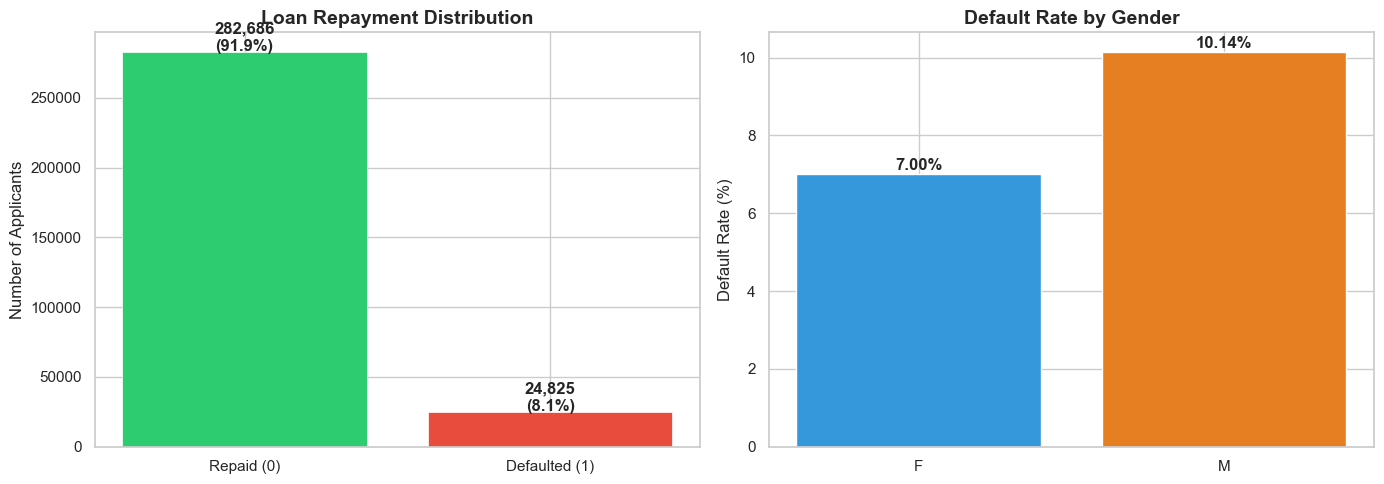

Chart 1 & 2 saved


In [7]:
# ================================================
# Visualizations
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Target distribution
target_counts = df['TARGET'].value_counts()
axes[0].bar(['Repaid (0)', 'Defaulted (1)'], target_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Loan Repayment Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Applicants')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')

# Chart 2: Default rate by gender
gender_default = df.groupby('CODE_GENDER')['TARGET'].mean() * 100
gender_default = gender_default[gender_default.index != 'XNA']
axes[1].bar(gender_default.index, gender_default.values,
            color=['#3498db', '#e67e22'], edgecolor='white')
axes[1].set_title('Default Rate by Gender', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
for i, v in enumerate(gender_default.values):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\namey\credit-risk-analysis\reports\screenshots\01_default_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 & 2 saved")

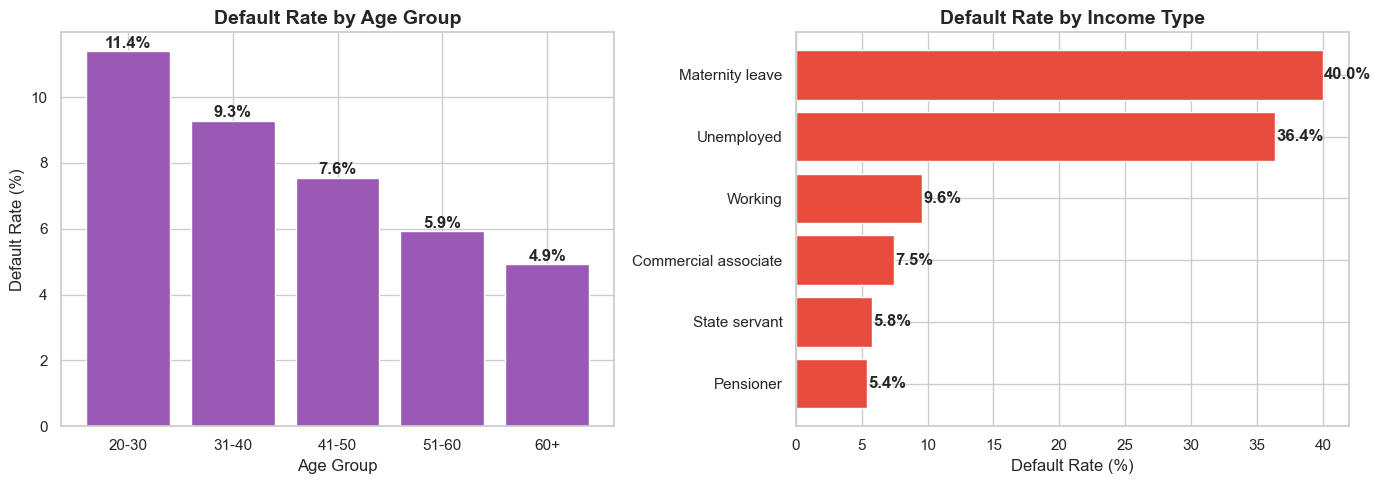

Chart 3 & 4 saved


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 3: Default rate by age group
age_default = df.groupby('AGE_GROUP', observed=True)['TARGET'].mean() * 100
axes[0].bar(age_default.index.astype(str), age_default.values,
            color='#9b59b6', edgecolor='white')
axes[0].set_title('Default Rate by Age Group', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_xlabel('Age Group')
for i, v in enumerate(age_default.values):
    axes[0].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 4: Default rate by income type (top 6)
income_default = df.groupby('NAME_INCOME_TYPE')['TARGET'].mean() * 100
income_default = income_default.sort_values(ascending=True).tail(6)
axes[1].barh(income_default.index, income_default.values,
             color='#e74c3c', edgecolor='white')
axes[1].set_title('Default Rate by Income Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Default Rate (%)')
for i, v in enumerate(income_default.values):
    axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\namey\credit-risk-analysis\reports\screenshots\02_age_income.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 & 4 saved")

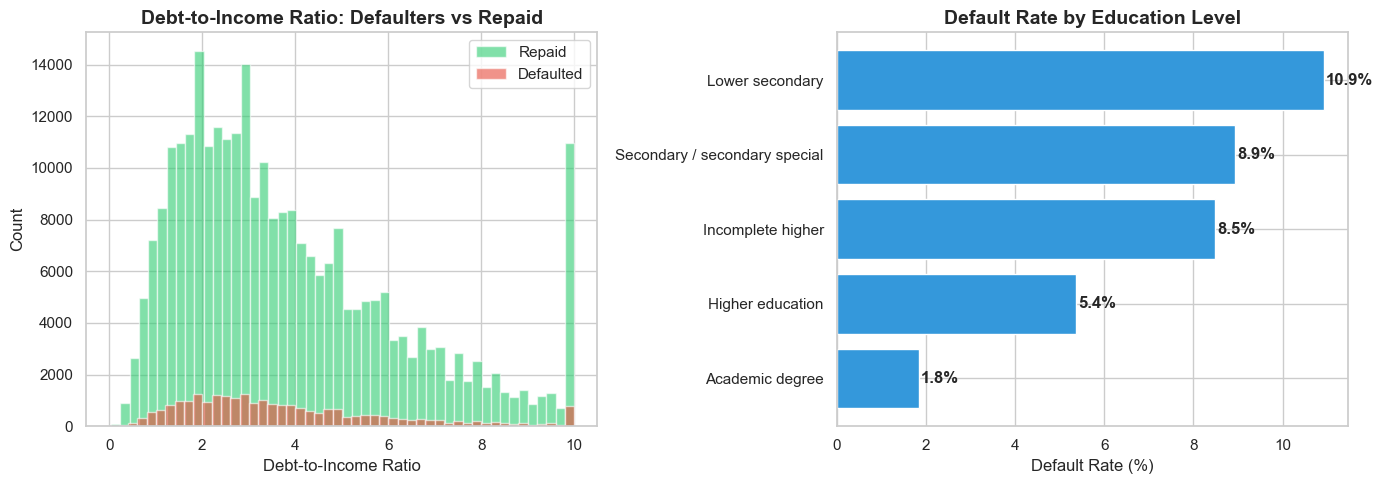

Chart 5 & 6 saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 5: Debt-to-income ratio distribution by target
df[df['TARGET'] == 0]['DEBT_TO_INCOME'].clip(0, 10).plot(
    kind='hist', bins=50, ax=axes[0], alpha=0.6,
    color='#2ecc71', label='Repaid')
df[df['TARGET'] == 1]['DEBT_TO_INCOME'].clip(0, 10).plot(
    kind='hist', bins=50, ax=axes[0], alpha=0.6,
    color='#e74c3c', label='Defaulted')
axes[0].set_title('Debt-to-Income Ratio: Defaulters vs Repaid',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Debt-to-Income Ratio')
axes[0].set_ylabel('Count')
axes[0].legend()

# Chart 6: Default rate by education
edu_default = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean() * 100
edu_default = edu_default.sort_values(ascending=True)
axes[1].barh(edu_default.index, edu_default.values,
             color='#3498db', edgecolor='white')
axes[1].set_title('Default Rate by Education Level',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Default Rate (%)')
for i, v in enumerate(edu_default.values):
    axes[1].text(v + 0.05, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\namey\credit-risk-analysis\reports\screenshots\03_debt_education.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 & 6 saved")

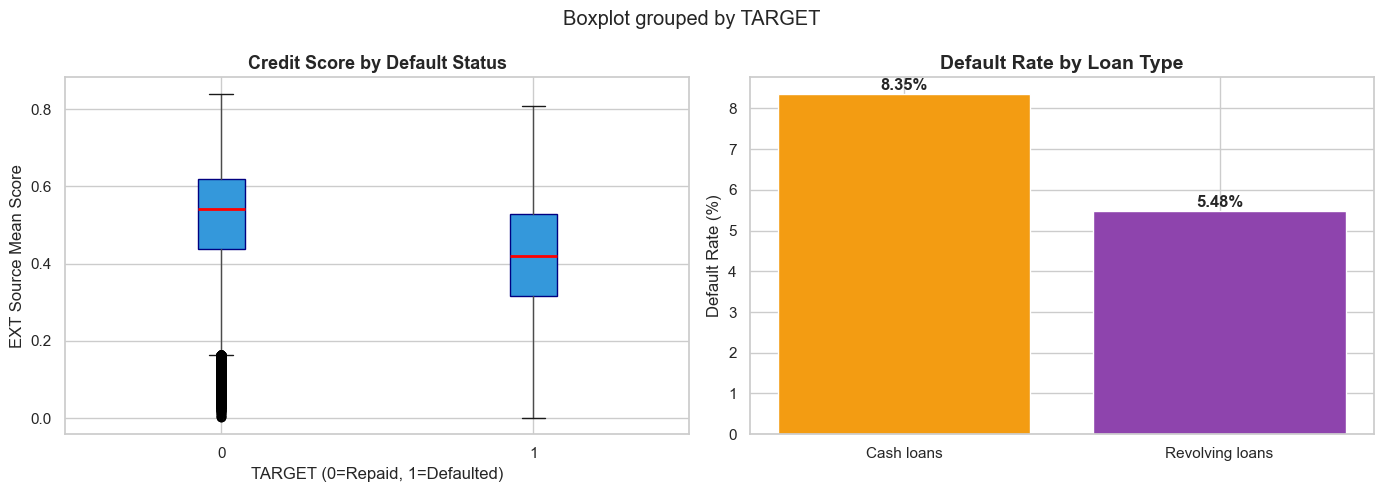

Chart 7 & 8 saved


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 7: EXT_SOURCE_MEAN by target (boxplot)
df.boxplot(column='EXT_SOURCE_MEAN', by='TARGET', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', color='navy'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Credit Score (EXT_SOURCE_MEAN) by Default Status',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('TARGET (0=Repaid, 1=Defaulted)')
axes[0].set_ylabel('EXT Source Mean Score')
plt.sca(axes[0])
plt.title('Credit Score by Default Status', fontsize=13, fontweight='bold')

# Chart 8: Default rate by loan type
loan_default = df.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean() * 100
axes[1].bar(loan_default.index, loan_default.values,
            color=['#f39c12', '#8e44ad'], edgecolor='white')
axes[1].set_title('Default Rate by Loan Type', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
for i, v in enumerate(loan_default.values):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\namey\credit-risk-analysis\reports\screenshots\04_extsource_loantype.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 & 8 saved")

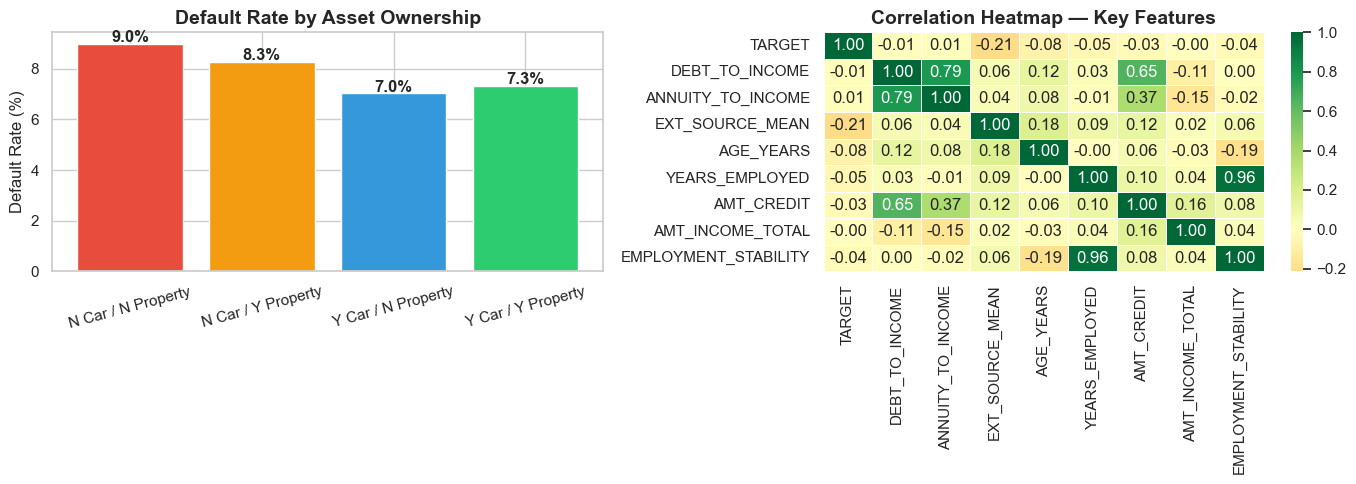

Chart 9 & 10 saved


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 9: Default rate by asset ownership
asset_groups = df.groupby(['FLAG_OWN_CAR', 'FLAG_OWN_REALTY'])['TARGET'].mean() * 100
asset_groups = asset_groups.reset_index()
asset_groups['Group'] = (asset_groups['FLAG_OWN_CAR'] + ' Car / ' +
                         asset_groups['FLAG_OWN_REALTY'] + ' Property')
axes[0].bar(asset_groups['Group'], asset_groups['TARGET'],
            color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'],
            edgecolor='white')
axes[0].set_title('Default Rate by Asset Ownership',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Default Rate (%)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(asset_groups['TARGET']):
    axes[0].text(i, v + 0.05, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 10: Correlation heatmap of key numeric features
key_features = [
    'TARGET', 'DEBT_TO_INCOME', 'ANNUITY_TO_INCOME',
    'EXT_SOURCE_MEAN', 'AGE_YEARS', 'YEARS_EMPLOYED',
    'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'EMPLOYMENT_STABILITY'
]
corr = df[key_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[1], linewidths=0.5, center=0)
axes[1].set_title('Correlation Heatmap — Key Features',
                  fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\namey\credit-risk-analysis\reports\screenshots\05_assets_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 9 & 10 saved")

In [12]:
# Save processed dataset for modelling
save_path = r'C:\Users\namey\credit-risk-analysis\data\processed\clean_data.csv'
df.to_csv(save_path, index=False)
print(f" Clean data saved!")
print(f"   Shape: {df.shape}")
print(f"   Location: data/processed/clean_data.csv")

 Clean data saved!
   Shape: (307511, 87)
   Location: data/processed/clean_data.csv
